# Imports


In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
from collections import deque

# Define Approximation Network, Epsilon Greedy Policy, ReplayBuffer, Hyperparameters

In [2]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.stack = nn.Sequential( 
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )
    # first logit is push left, second logit is push right
    def forward(self, x):
        logits = self.stack(x)
        return logits

In [3]:
class ReplayBuffer:
    def __init__(self, batch_size):
        self.d = deque(maxlen=10000)
        self.batch_size = batch_size

    def append(self, sequence):
        self.d.append(sequence)
    
    def sample(self):
        return random.sample(self.d, self.batch_size)
    
    def __len__(self):
        return len(self.d)


In [4]:
def select_action(state, epsilon, online_network):
    if random.random() > epsilon:
        state = state.clone().detach()
        with torch.no_grad():
            action = torch.argmax(online_network(state)).item()
    else:
        action = random.randint(0, 1)
    return action

hyperparameters (given by claude)

In [5]:
gamma = 0.99              # discount factor, close to 1 since cartpole is not too long
epsilon = 1.0             # start fully random
epsilon_min = 0.01        # never stop exploring completely
epsilon_decay = 0.995    # multiply epsilon by this each episode
batch_size = 64          # number of transitions to sample from buffer
lr = 0.0001                # learning rate for optimizer
target_update_freq = 50   # copy w into w- every 10 episodes
num_episodes = 3000        # number of episodes to train for

# Training Loop

In [6]:
env = gym.make("CartPole-v1")

In [7]:
target_network = Network()
online_network = Network()
target_network.load_state_dict(online_network.state_dict())
replay_buffer = ReplayBuffer(64)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(online_network.parameters(), lr=.001)
episode_rewards = []

In [8]:
for i in range(1, num_episodes+1):
    # reset the environment
    obs, info = env.reset()
    terminated = 0
    truncated = 0
    total_reward = 0
    while not (terminated or truncated): 
        state = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)  # [1, 4]
        # pick epsilon greedy action and store it in the buffer
        action = select_action(state, epsilon, online_network)
        observation, reward, terminated, truncated, info = env.step(action)
        obs = observation
        total_reward += reward
        replay_buffer.append((state, action, reward, observation, terminated))
        if len(replay_buffer) > 1000:
            batch = replay_buffer.sample()  # list of 64 tuples: (state, action, reward, next_state, done)
            states, actions, rewards, next_states, dones = zip(*batch)  # each is a tuple of 64 elements

            # convert to tensors
            states = torch.cat(states, dim=0) # [64, 4]
            rewards = torch.tensor(rewards, dtype=torch.float32) # [64]
            dones = torch.tensor(dones, dtype=torch.float32) # [64]
            # compute targets using frozen target network
            with torch.no_grad():
                next_states = torch.tensor(np.array(next_states), dtype=torch.float32)  # [64, 4]
                max_next_q = torch.max(target_network(next_states), dim=1).values # [64]
                targets = rewards + gamma * max_next_q * (1 - dones) # [64]

            # compute predictions from online network for actions that were actually taken
            actions_tensor = torch.tensor(actions, dtype=torch.long) # [64]
            predicted_q = online_network(states).gather(1, actions_tensor.unsqueeze(1)).squeeze(1) # [64]

            # compute loss and update weights
            optimizer.zero_grad()
            loss = criterion(predicted_q, targets)
            loss.backward()
            optimizer.step()

    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    if i % target_update_freq == 0:
        target_network.load_state_dict(online_network.state_dict())
    if i % 50 == 0:
        print(f"Episode {i} | Avg Reward (last 50): {np.mean(episode_rewards[-50:]):.1f} | Epsilon: {epsilon:.3f}")

Episode 50 | Avg Reward (last 50): 22.4 | Epsilon: 0.778
Episode 100 | Avg Reward (last 50): 16.3 | Epsilon: 0.606
Episode 150 | Avg Reward (last 50): 19.7 | Epsilon: 0.471
Episode 200 | Avg Reward (last 50): 34.2 | Epsilon: 0.367
Episode 250 | Avg Reward (last 50): 77.6 | Epsilon: 0.286
Episode 300 | Avg Reward (last 50): 127.7 | Epsilon: 0.222
Episode 350 | Avg Reward (last 50): 187.6 | Epsilon: 0.173
Episode 400 | Avg Reward (last 50): 167.2 | Epsilon: 0.135
Episode 450 | Avg Reward (last 50): 129.6 | Epsilon: 0.105
Episode 500 | Avg Reward (last 50): 126.0 | Epsilon: 0.082
Episode 550 | Avg Reward (last 50): 168.0 | Epsilon: 0.063
Episode 600 | Avg Reward (last 50): 179.0 | Epsilon: 0.049
Episode 650 | Avg Reward (last 50): 158.1 | Epsilon: 0.038
Episode 700 | Avg Reward (last 50): 219.1 | Epsilon: 0.030
Episode 750 | Avg Reward (last 50): 168.6 | Epsilon: 0.023
Episode 800 | Avg Reward (last 50): 176.5 | Epsilon: 0.018
Episode 850 | Avg Reward (last 50): 144.2 | Epsilon: 0.014
Epi

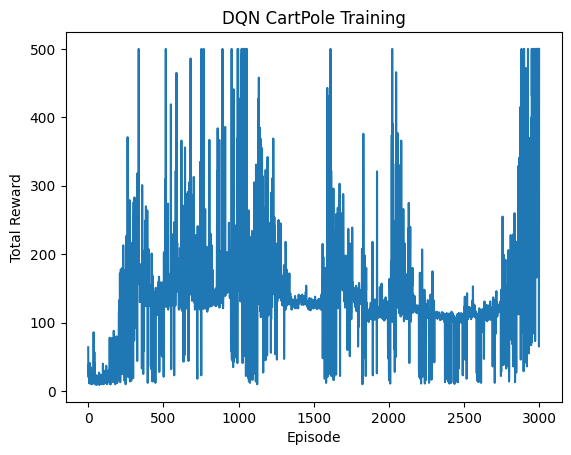

In [9]:
plt.plot(episode_rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('DQN CartPole Training')
plt.show()

In [11]:
env_render = gym.make("CartPole-v1", render_mode="human")
obs, info = env_render.reset()
terminated = False
truncated = False
total_reward = 0

while not (terminated or truncated):
    state = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)  # [1, 4]
    with torch.no_grad():
        action = torch.argmax(online_network(state)).item()  # pure greedy, no epsilon
    obs, reward, terminated, truncated, info = env_render.step(action)
    total_reward += reward

print(f"Total Reward: {total_reward}")
env_render.close()

Total Reward: 500.0
